# Predicted vs Actual Attribution

Compares attributions for:
1. **Predicted** activity (what the model outputs)
2. **Actual** activity (ground truth)
3. **Delta** (what features would need to change to get the correct answer)

In [1]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.interpretability.config.bpic17_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

In [2]:
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

# Get activity mapping
concept_id = eval_helper.concept_name_id
inv_cats = eval_helper.inverted_suffix_categories[concept_id]
cat_to_idx = {v: k for k, v in inv_cats.items()}

print(f"Cases: {len(eval_helper.cases)}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

In [3]:
# Configuration
CASE_NAME = list(eval_helper.cases.keys())[0]  # Pick first available case
PREFIX_LENGTH = 2
SUFFIX_STEP = 0  # Which suffix step to analyze

# Get prefix and ground truth
case = eval_helper.cases[CASE_NAME]
for pl, prefix, suffix in eval_helper._iterate_case(case):
    if pl == PREFIX_LENGTH:
        break

# Ground truth activity
gt_idx = suffix[0][concept_id][0, SUFFIX_STEP].item()
gt_activity = inv_cats.get(gt_idx, f'?{gt_idx}')

# Model prediction
with torch.no_grad():
    predictions, _, _, _ = model(prefix)
cat_preds = predictions[0]
activity_logits = cat_preds[f'{CONFIG.concept_name}_mean']
if activity_logits.dim() == 3:
    activity_logits = activity_logits[SUFFIX_STEP]
pred_idx = activity_logits.argmax(dim=-1).item()
pred_activity = inv_cats.get(pred_idx, f'?{pred_idx}')

is_correct = pred_idx == gt_idx

print(f"Case: {CASE_NAME}, Prefix: {PREFIX_LENGTH}, Suffix step: {SUFFIX_STEP}")
print(f"Predicted: {pred_activity} (class {pred_idx})")
print(f"Actual:    {gt_activity} (class {gt_idx})")
print(f"Correct:   {is_correct}")

Case: Application_1000086665, Prefix: 2, Suffix step: 0
Predicted: W_Handle leads (class 24)
Actual:    W_Handle leads (class 24)
Correct:   True


In [4]:
# Compute attributions for predicted and actual classes
cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
process = (cat_tensors, num_tensors)

# Attribution for predicted class
attr_predicted = tool.compute_attribution_map(
    process=process,
    prefix_length=PREFIX_LENGTH,
    target=CONFIG.concept_name,
    target_class=pred_idx,
    suffix_scope='step',
    suffix_step=SUFFIX_STEP,
    method='integrated_gradients',
    n_steps=CONFIG.ig_steps
)

# Attribution for actual class
attr_actual = tool.compute_attribution_map(
    process=process,
    prefix_length=PREFIX_LENGTH,
    target=CONFIG.concept_name,
    target_class=gt_idx,
    suffix_scope='step',
    suffix_step=SUFFIX_STEP,
    method='integrated_gradients',
    n_steps=CONFIG.ig_steps
)

feature_names = attr_predicted.feature_names
step_labels = attr_predicted.step_labels

print(f"Predicted attribution target: {attr_predicted.target_description}")
print(f"Actual attribution target:    {attr_actual.target_description}")
print(f"Features: {len(feature_names)}, Steps: {len(step_labels)}")

Predicted attribution target: concept:name = W_Handle leads (class 24) [integrated_gradients]
Actual attribution target:    concept:name = W_Handle leads (class 24) [integrated_gradients]
Features: 18, Steps: 3


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_3059/303456286.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


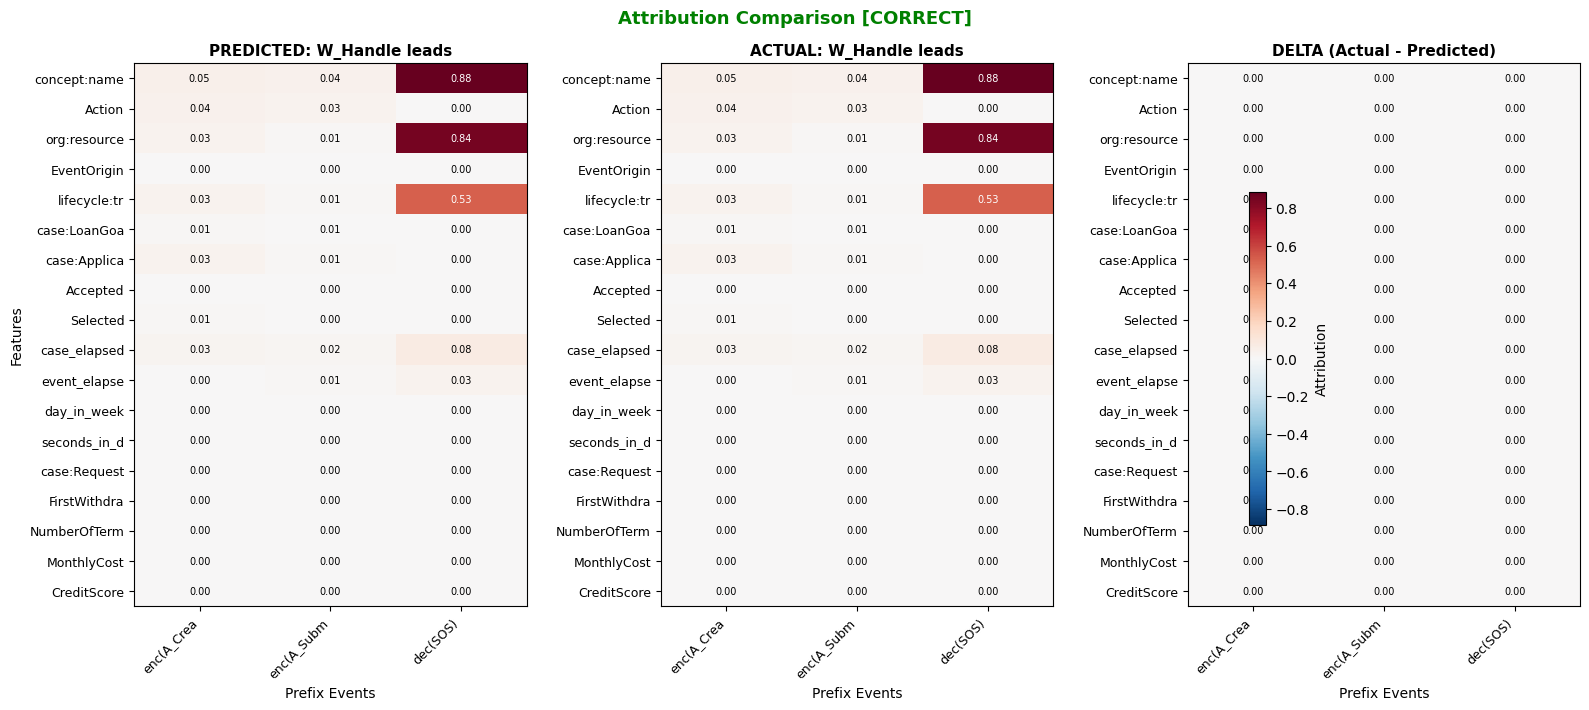

In [5]:
def to_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.array(x)

def plot_comparison(attr_pred, attr_actual, feature_names, step_labels, 
                    pred_activity, gt_activity, is_correct):
    """Side-by-side comparison of predicted vs actual attributions."""
    n_features = len(feature_names)
    n_steps = len(step_labels)
    
    # Build matrices
    mat_pred = np.array([to_numpy(attr_pred.attributions[f]) for f in feature_names])
    mat_actual = np.array([to_numpy(attr_actual.attributions[f]) for f in feature_names])
    mat_delta = mat_actual - mat_pred
    
    # Find global vmax for consistent scaling
    vmax = max(np.abs(mat_pred).max(), np.abs(mat_actual).max(), np.abs(mat_delta).max())
    
    fig, axes = plt.subplots(1, 3, figsize=(16, max(6, n_features * 0.4)))
    
    titles = [
        f'PREDICTED: {pred_activity}',
        f'ACTUAL: {gt_activity}',
        f'DELTA (Actual - Predicted)'
    ]
    matrices = [mat_pred, mat_actual, mat_delta]
    
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap='RdBu_r', aspect='auto',
                      norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
        
        ax.set_xticks(range(n_steps))
        ax.set_xticklabels([l[:10] for l in step_labels], rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(n_features))
        ax.set_yticklabels([f[:12] for f in feature_names], fontsize=9)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Prefix Events')
        
        # Add value annotations
        for i in range(n_features):
            for j in range(n_steps):
                val = mat[i, j]
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                       fontsize=7, color=color)
    
    axes[0].set_ylabel('Features')
    
    # Colorbar
    fig.colorbar(im, ax=axes, shrink=0.6, label='Attribution')
    
    status = "CORRECT" if is_correct else "INCORRECT"
    status_color = 'green' if is_correct else 'red'
    fig.suptitle(f'Attribution Comparison [{status}]', fontsize=13, fontweight='bold', color=status_color)
    plt.tight_layout()
    return fig, mat_pred, mat_actual, mat_delta

fig, mat_pred, mat_actual, mat_delta = plot_comparison(
    attr_predicted, attr_actual, feature_names, step_labels,
    pred_activity, gt_activity, is_correct
)
plt.show()

In [6]:
# Summary: which features differ most?
print(f"{'='*70}")
print(f"DELTA ANALYSIS: What would push toward the correct answer?")
print(f"{'='*70}")

# Total delta per feature
delta_totals = np.sum(mat_delta, axis=1)  # Sum across positions
sorted_idx = np.argsort(np.abs(delta_totals))[::-1]

print(f"\nFeatures with largest delta (Actual - Predicted):")
print(f"  Positive delta = feature pushes MORE toward actual class")
print(f"  Negative delta = feature pushes LESS toward actual class\n")

for rank, idx in enumerate(sorted_idx[:8], 1):
    feat = feature_names[idx]
    delta = delta_totals[idx]
    pred_val = np.sum(mat_pred[idx])
    actual_val = np.sum(mat_actual[idx])
    
    direction = "+" if delta > 0 else "-"
    print(f"  {rank}. {feat:20s}: delta={delta:+.4f}  (pred={pred_val:.4f}, actual={actual_val:.4f})")

DELTA ANALYSIS: What would push toward the correct answer?

Features with largest delta (Actual - Predicted):
  Positive delta = feature pushes MORE toward actual class
  Negative delta = feature pushes LESS toward actual class

  1. CreditScore         : delta=+0.0000  (pred=0.0000, actual=0.0000)
  2. MonthlyCost         : delta=+0.0000  (pred=0.0000, actual=0.0000)
  3. Action              : delta=+0.0000  (pred=0.0714, actual=0.0714)
  4. org:resource        : delta=+0.0000  (pred=0.8849, actual=0.8849)
  5. EventOrigin         : delta=+0.0000  (pred=0.0038, actual=0.0038)
  6. lifecycle:transition: delta=+0.0000  (pred=0.5743, actual=0.5743)
  7. case:LoanGoal       : delta=+0.0000  (pred=0.0166, actual=0.0166)
  8. case:ApplicationType: delta=+0.0000  (pred=0.0460, actual=0.0460)
